# **Loan Approval Analysis & Prediction**

In [721]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings("ignore")

## Load the dataset and show the basic information

In [723]:
data = pd.read_csv('loan_approval.csv')
data.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45.0,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,NaN
1,2018-01-02,38.0,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47.0,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,NaN
3,2018-01-04,58.0,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,NaN
4,2018-01-05,37.0,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,NaN


In [724]:
# Get basic info of the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  object 
 1   Age                         19900 non-null  float64
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  object 
 5   EducationLevel              20000 non-null  object 
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               19900 non-null  object 
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  object 
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   200

In [725]:
# Get statistical info of the dataset
data.describe(include="all")

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
count,20000,19900.000000,20000.000000,20000.000000,20000,20000,20000.000000,20000.000000,20000.000000,19900,...,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,1000.000000
unique,20000,NaN,NaN,NaN,3,5,NaN,NaN,NaN,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2018-01-01,NaN,NaN,NaN,Employed,Bachelor,NaN,NaN,NaN,Married,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,17036,6054,NaN,NaN,NaN,9999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,39.751759,59161.473550,571.612400,NaN,NaN,17.522750,24882.867800,54.057000,NaN,...,4891.715521,0.799918,5.002650,7.229432e+04,0.239124,0.239110,911.607052,0.402182,0.239000,50.687600
std,NaN,11.630809,40350.845168,50.997358,NaN,NaN,11.316836,13427.421217,24.664857,NaN,...,3296.771598,0.120665,2.236804,1.179200e+05,0.035509,0.042205,674.583473,0.338924,0.426483,7.881033
min,NaN,18.000000,15000.000000,343.000000,NaN,NaN,0.000000,3674.000000,12.000000,NaN,...,1250.000000,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000,30.400000
25%,NaN,31.750000,31679.000000,540.000000,NaN,NaN,9.000000,15575.000000,36.000000,NaN,...,2629.583333,0.727379,3.000000,8.734750e+03,0.213889,0.209142,493.763700,0.179693,0.000000,46.000000
50%,NaN,40.000000,48566.000000,578.000000,NaN,NaN,17.000000,21914.500000,48.000000,NaN,...,4034.750000,0.820962,5.000000,3.285550e+04,0.236157,0.235390,728.511452,0.302711,0.000000,52.000000
75%,NaN,48.000000,74391.000000,609.000000,NaN,NaN,25.000000,30835.000000,72.000000,NaN,...,6163.000000,0.892333,6.000000,8.882550e+04,0.261533,0.265532,1112.770759,0.509214,0.000000,56.000000


In [726]:
print("Length of the data before cleaning:", len(data))

Length of the data before cleaning: 20000


## Clean the dataset

In [729]:
# If over 50% of the values of a column, the column should be removed from the data frame

# Identify which columns have null values
data.isnull().sum()

ApplicationDate                   0
Age                             100
AnnualIncome                      0
CreditScore                       0
EmploymentStatus                  0
EducationLevel                    0
Experience                        0
LoanAmount                        0
LoanDuration                      0
MaritalStatus                   100
NumberOfDependents                0
HomeOwnershipStatus               0
MonthlyDebtPayments               0
CreditCardUtilizationRate         0
NumberOfOpenCreditLines           0
NumberOfCreditInquiries           0
DebtToIncomeRatio                 0
BankruptcyHistory                 0
LoanPurpose                       0
PreviousLoanDefaults              0
PaymentHistory                    0
LengthOfCreditHistory             0
SavingsAccountBalance             0
CheckingAccountBalance            0
TotalAssets                       0
TotalLiabilities                  0
MonthlyIncome                     0
UtilityBillsPaymentHistory  

* Risk Score has more than 50% missing values. This column will be removed.
* Both Age and Marital Status have 100 missing values.
* Age's missing values will be imputed with mean.
* Marital Status' missing values will be removed accordingly.

In [731]:
# Drop Risk Score Column
data = data.drop(['RiskScore'], axis = 1)

# Check if Risk Score Column has been removed
if 'RiskScore' in data:
    print("Risk Score column NOT removed.")
else:
    print("Risk Score column removed.")

Risk Score column removed.


In [732]:
# For a categorical column (Marital Status), if a row contains a missing value, you need to delete the whole row;

# Check current shape of Marital Status
print("Marital Status shape before dropping null values:", data['MaritalStatus'].shape)

# Drop entire row of Marital Status' null values
data.dropna(subset=['MaritalStatus'], inplace=True)

# Check new shape of Marital Status
print("Marital Status shape after dropping null values:", data['MaritalStatus'].shape)

Marital Status shape before dropping null values: (20000,)
Marital Status shape after dropping null values: (19900,)


In [733]:
# For a numerical column (Age), if a row contains a missing value, you need to perform a missing value imputation with the average value of the column.

# Locate one missing value of Age before imputation
data.loc[data['Age'].isnull()].head(1)

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved
78,2018-03-20,NaN,92731,619,Employed,Bachelor,19,31116,48,Single,...,14838,7727.583333,0.553711,3,7629,0.216616,0.215425,972.630201,0.17711,0


In [734]:
# Average value imputation for Age columns' missing values
data['Age'].fillna(data['Age'].mean(), inplace = True)

# Verify Age null values has successfully been replaced based on one sample
data.loc[[78]]

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved
78,2018-03-20,39.755455,92731,619,Employed,Bachelor,19,31116,48,Single,...,14838,7727.583333,0.553711,3,7629,0.216616,0.215425,972.630201,0.17711,0


In [735]:
# Check if there any missing values left
print("Remaining missing values:", data.isnull().sum().sum())

Remaining missing values: 0


### Handle categorical attributes
1. If all the categorical values of a column are unique, this column does not provide any statistical informaiton and should be deleted.
2. Use one hot encoding to convert the categorical values into numerical ones.

In [737]:
# If all the categorical values of a column are unique, this column does not provide any statistical informaiton and should be deleted.

# Check categorical columns' unique values
# Consider Application Date as categorical
data.describe(include='all')

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved
count,19900,19900.000000,19900.000000,19900.000000,19900,19900,19900.000000,19900.000000,19900.000000,19900,...,1.990000e+04,19900.000000,19900.000000,19900.000000,1.990000e+04,19900.000000,19900.000000,19900.000000,19900.000000,19900.000000
unique,19900,NaN,NaN,NaN,3,5,NaN,NaN,NaN,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2018-01-01,NaN,NaN,NaN,Employed,Bachelor,NaN,NaN,NaN,Married,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,16953,6020,NaN,NaN,NaN,9999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,39.755455,59149.157739,571.579045,NaN,NaN,17.527487,24882.674523,54.067538,NaN,...,3.625414e+04,4890.496202,0.799855,5.002261,7.222712e+04,0.239149,0.239137,911.294816,0.402078,0.238191
std,NaN,11.603973,40340.641813,51.016271,NaN,NaN,11.319663,13434.035867,24.667393,NaN,...,4.728501e+04,3295.557123,0.120621,2.236853,1.176969e+05,0.035512,0.042195,674.261264,0.338466,0.425987
min,NaN,18.000000,15000.000000,343.000000,NaN,NaN,0.000000,3674.000000,12.000000,NaN,...,3.720000e+02,1250.000000,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000
25%,NaN,32.000000,31688.250000,540.000000,NaN,NaN,9.000000,15575.000000,36.000000,NaN,...,1.119500e+04,2630.083333,0.727352,3.000000,8.729250e+03,0.213916,0.209198,493.763700,0.179853,0.000000
50%,NaN,40.000000,48577.000000,578.000000,NaN,NaN,17.000000,21915.500000,48.000000,NaN,...,2.220050e+04,4035.041667,0.820872,5.000000,3.284550e+04,0.236176,0.235436,728.511452,0.302719,0.000000
75%,NaN,48.000000,74372.000000,609.000000,NaN,NaN,25.000000,30828.250000,72.000000,NaN,...,4.313500e+04,6161.062500,0.892278,6.000000,8.882125e+04,0.261571,0.265530,1112.478552,0.509294,0.000000


In [738]:
# Drop Application Date Column as its entries are all unique
data = data.drop(['ApplicationDate'], axis=1)

In [739]:
# Use one hot encoding to convert the categorical values into numerical ones
data = pd.get_dummies(data, columns = ['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose'])
data.head(1)

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,MaritalStatus_Widowed,HomeOwnershipStatus_Mortgage,HomeOwnershipStatus_Other,HomeOwnershipStatus_Own,HomeOwnershipStatus_Rent,LoanPurpose_Auto,LoanPurpose_Debt Consolidation,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other
0,45.0,39948,617,22,13152,48,2,183,0.354418,1,...,False,False,False,True,False,False,False,False,True,False


In [740]:
# Convert boolean values to binary
data[['EmploymentStatus_Employed', 'EmploymentStatus_Self-Employed', 'EmploymentStatus_Unemployed', 'EducationLevel_Associate', 
      'EducationLevel_Bachelor', 'EducationLevel_Doctorate', 'EducationLevel_High School', 'EducationLevel_Master', 'MaritalStatus_Divorced', 
      'MaritalStatus_Married', 'MaritalStatus_Single', 'MaritalStatus_Widowed', 'HomeOwnershipStatus_Mortgage', 'HomeOwnershipStatus_Other', 
      'HomeOwnershipStatus_Own', 'HomeOwnershipStatus_Rent', 'LoanPurpose_Auto', 'LoanPurpose_Debt Consolidation', 'LoanPurpose_Education', 
      'LoanPurpose_Home', 'LoanPurpose_Other']] = data[['EmploymentStatus_Employed', 'EmploymentStatus_Self-Employed', 'EmploymentStatus_Unemployed', 
                                                        'EducationLevel_Associate', 'EducationLevel_Bachelor', 'EducationLevel_Doctorate', 
                                                        'EducationLevel_High School', 'EducationLevel_Master', 'MaritalStatus_Divorced', 
                                                        'MaritalStatus_Married', 'MaritalStatus_Single', 'MaritalStatus_Widowed', 
                                                        'HomeOwnershipStatus_Mortgage', 'HomeOwnershipStatus_Other', 'HomeOwnershipStatus_Own', 
                                                        'HomeOwnershipStatus_Rent', 'LoanPurpose_Auto', 'LoanPurpose_Debt Consolidation', 
                                                        'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other']].astype(int)

In [741]:
# Check new dataframe with data dropped, new data from one hot encoding and its data type
data.head(1)

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,MaritalStatus_Widowed,HomeOwnershipStatus_Mortgage,HomeOwnershipStatus_Other,HomeOwnershipStatus_Own,HomeOwnershipStatus_Rent,LoanPurpose_Auto,LoanPurpose_Debt Consolidation,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other
0,45.0,39948,617,22,13152,48,2,183,0.354418,1,...,0,0,0,1,0,0,0,0,1,0


In [742]:
print("Length of the data after cleaning:", len(data))
data.info()

Length of the data after cleaning: 19900
<class 'pandas.core.frame.DataFrame'>
Index: 19900 entries, 0 to 19999
Data columns (total 50 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             19900 non-null  float64
 1   AnnualIncome                    19900 non-null  int64  
 2   CreditScore                     19900 non-null  int64  
 3   Experience                      19900 non-null  int64  
 4   LoanAmount                      19900 non-null  int64  
 5   LoanDuration                    19900 non-null  int64  
 6   NumberOfDependents              19900 non-null  int64  
 7   MonthlyDebtPayments             19900 non-null  int64  
 8   CreditCardUtilizationRate       19900 non-null  float64
 9   NumberOfOpenCreditLines         19900 non-null  int64  
 10  NumberOfCreditInquiries         19900 non-null  int64  
 11  DebtToIncomeRatio               19900 non-null  float64
 

## Build a logistic regression classification model
### Specify the features and the label, and split the dataset into training data and testing data

In [745]:
# Create new variables to store features
feat1 = ['EmploymentStatus_Employed', 'EmploymentStatus_Self-Employed', 'EmploymentStatus_Unemployed', 'EducationLevel_Associate', 
         'EducationLevel_Bachelor', 'EducationLevel_Doctorate', 'EducationLevel_High School', 'EducationLevel_Master', 
         'MaritalStatus_Divorced','MaritalStatus_Married', 'MaritalStatus_Single', 'MaritalStatus_Widowed', 
         'HomeOwnershipStatus_Mortgage', 'HomeOwnershipStatus_Other', 'HomeOwnershipStatus_Own', 'HomeOwnershipStatus_Rent', 
         'LoanPurpose_Auto', 'LoanPurpose_Debt Consolidation', 'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other', 
         'BankruptcyHistory', 'PreviousLoanDefaults']

feat2 = ['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 
         'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 
         'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'JobTenure', 'NetWorth', 'BaseInterestRate', 
         'InterestRate', 'CreditCardUtilizationRate', 'DebtToIncomeRatio', 'UtilityBillsPaymentHistory', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio']

# Specify the features and the label (The attirbute "LoanApproved" is the label, which is the prediction target. 
# The remaining attributes are the features.)

features = data[feat1 + feat2]
label = data['LoanApproved']

# The ratio for splitting the dataset is 80% for training and 20% for testing. 
# Note that you need to set the "random_state" parameter as your student ID to produce your personlised splitting. Failing to do so will lose marks.
X_train, X_test, y_train, y_test = train_test_split(features, label, test_size=0.2, random_state = 48573345)

### Build a logistic regression model

In [747]:
# Build logistic regressio model
lr_model = LogisticRegression()

# Train a logistic regression model
lr_model.fit(X_train, y_train)

# Predict on test set
y_test_pred = lr_model.predict(X_test)

# Report two classification performance metrics on the testing data 
print("Testing Data Accuracy Score:", accuracy_score(y_test, y_test_pred))
print("Testing Data F1 Score:", f1_score(y_test, y_test_pred))

Testing Data Accuracy Score: 0.892462311557789
Testing Data F1 Score: 0.7598204264870931


In [748]:
# Also report the two metrics on the training data, and compare the results with that of the testing data. 

# Predict on training set
y_train_pred = lr_model.predict(X_train)

# Print the training set results
print("Training Data Accuracy Score:", accuracy_score(y_train, y_train_pred))
print("Training Data F1 Score:", f1_score(y_train, y_train_pred))

Training Data Accuracy Score: 0.8873115577889448
Training Data F1 Score: 0.7501392757660167


Accuracy indicates the correctness of the model in successfully predicting the outcome. In this context, accuracy refers to how correctly the model predicts whether a loan application will be approved or not. Accuracy is measured by number of correct predictions divided by the total number of predictions.
* In **Testing Data**, 89.25% of loan approval predictions are correct. This suggests that the model is performing very well on unseen data.
* In **Training Data**, this model also performed well with an accuracy score of 88.73%.

F1 Score is typically used of imbalanced dataset. This balances both precision and recall to handle false positives and false negatives predictions. Precision refers to the ratio of predicted approval that are actually correct while recall refers to the ratio of actual approvals that are correctly predicted. In the loan approval context, precision provides the percentage of loans that are predicted as approved and were actually approved (true positive and false positive). Recall is the percentage of the actual approved loans that were correctly predicted (true positive and false negative).
* **Testing Data** and **Training Data** scored 75.98% and 75.01% respectively, these percentages represents the balance between predicted and actual loan approval captured, suggesting a good balance between precision and recall.

As the Accuracy Scores and F1 Scores of both testing and training data have very little difference, this means that the model is not overfitting and performs consistently on training data and unseen data.

### Perform the recursive feature elimination (RFE) technique to identify the effective features for building the model

In [751]:
# Perform the recursive feature elimination (RFE) technique to identify the effective features for building the model 

# Build the Logistic Regression Model
lr_model = LogisticRegression()

# Perform RFE
rfe = RFE(estimator=lr_model, n_features_to_select=10, step=1)

# Train RFE
rfe.fit(X_train, y_train)

# Predict
y_test_predict = rfe.predict(X_test)

# Print the results
print("Accuracy score on test set: ", accuracy_score(y_test, y_test_predict))
print("F1 score on test set: ", f1_score(y_test, y_test_predict))

Accuracy score on test set:  0.8974874371859296
F1 score on test set:  0.7763157894736842


In [752]:
# Visualise the change of the two performance metrics with respect to the number of eliminated features using a line chart

# Get Accuracy Scores per feature

# Create a variable to store feature accuracy scores
acc_scores = []

# Use for loop to get the accuracy scores per feature
for i in range(1, len(feat1 + feat2) + 1):
    # Build the model
    rfe = RFE(estimator=lr_model, n_features_to_select=i)

    # Train the model
    rfe.fit(X_train, y_train)

    # Predict
    y_pred = rfe.predict(X_test)
    acc_score = accuracy_score(y_test, y_pred)


    # Print the results
    print("Acc on test set using", i, "features: ", acc_score)

    
    # Add the accuracy score to list
    acc_scores.append(acc_score)

Acc on test set using 1 features:  0.764321608040201
Acc on test set using 2 features:  0.8902010050251257
Acc on test set using 3 features:  0.8884422110552764
Acc on test set using 4 features:  0.8922110552763819
Acc on test set using 5 features:  0.8909547738693467
Acc on test set using 6 features:  0.892964824120603
Acc on test set using 7 features:  0.8922110552763819
Acc on test set using 8 features:  0.892964824120603
Acc on test set using 9 features:  0.8967336683417085
Acc on test set using 10 features:  0.8974874371859296
Acc on test set using 11 features:  0.8964824120603015
Acc on test set using 12 features:  0.8979899497487437
Acc on test set using 13 features:  0.8974874371859296
Acc on test set using 14 features:  0.8889447236180904
Acc on test set using 15 features:  0.8816582914572865
Acc on test set using 16 features:  0.8874371859296483
Acc on test set using 17 features:  0.8889447236180904
Acc on test set using 18 features:  0.8899497487437186
Acc on test set using 

In [753]:
# Get F1 Scores per feature

# Create a variable to store feature f1 scores
f1_scores = []

# Use for loop to get the f1 scores per feature
for i in range(1, len(feat1 + feat2) + 1):
    # Build the model
    rfe = RFE(estimator=lr_model, n_features_to_select=i)

    # Train the model
    rfe.fit(X_train, y_train)

    # Predict
    y_pred = rfe.predict(X_test)
    f1 = f1_score(y_test, y_pred)


    # Print the results
    print("F1 on test set using", i, "features: ", f1)

    # Add the F1 score to list
    f1_scores.append(f1)

F1 on test set using 1 features:  0.05060728744939271
F1 on test set using 2 features:  0.756816917084029
F1 on test set using 3 features:  0.754424778761062
F1 on test set using 4 features:  0.7617990005552471
F1 on test set using 5 features:  0.7599557522123894
F1 on test set using 6 features:  0.7622767857142857
F1 on test set using 7 features:  0.7623268698060942
F1 on test set using 8 features:  0.7654185022026432
F1 on test set using 9 features:  0.773303916161059
F1 on test set using 10 features:  0.7763157894736842
F1 on test set using 11 features:  0.7741228070175439
F1 on test set using 12 features:  0.7766776677667767
F1 on test set using 13 features:  0.775330396475771
F1 on test set using 14 features:  0.7597826086956522
F1 on test set using 15 features:  0.7419178082191781
F1 on test set using 16 features:  0.7485970819304153
F1 on test set using 17 features:  0.7555309734513275
F1 on test set using 18 features:  0.7574750830564784
F1 on test set using 19 features:  0.761

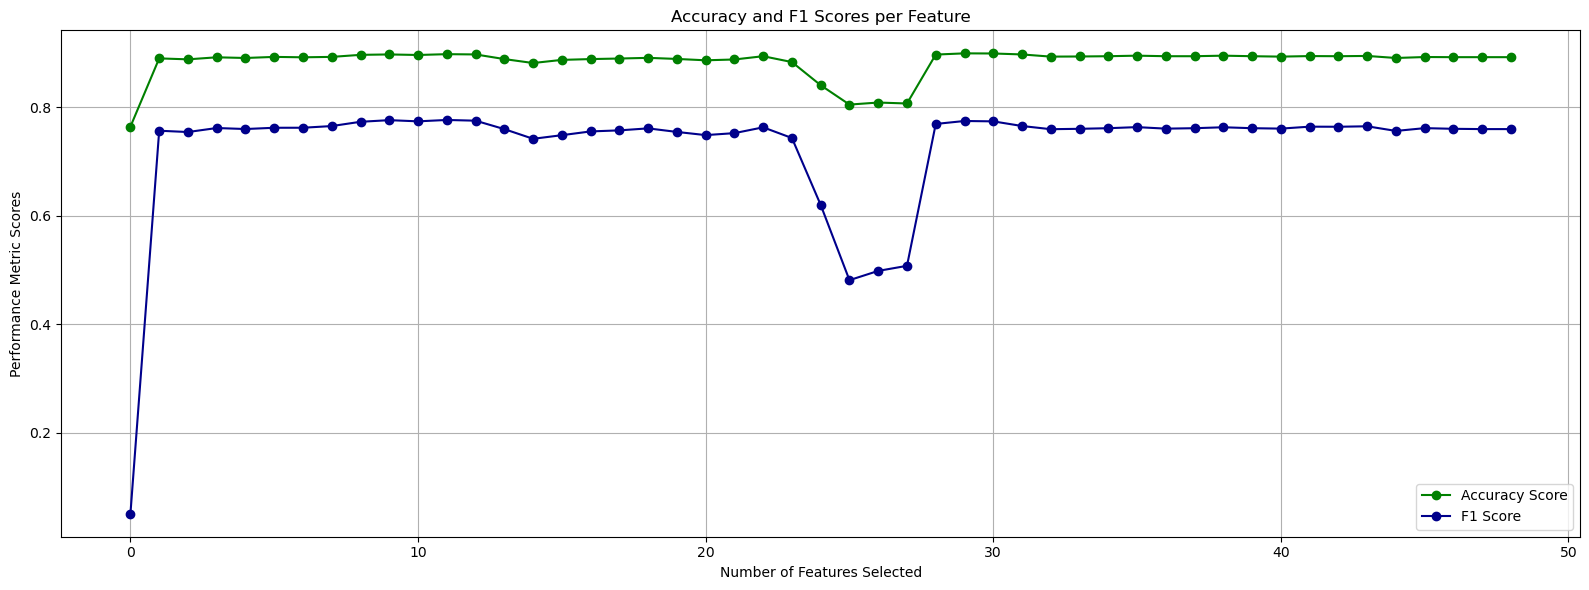

In [754]:
# Line chart visualization to show the change of Accuracy and F1 Scores per Number of Features
plt.figure(figsize = (16,6))

plt.plot(acc_scores, marker = 'o', color ='green', label = 'Accuracy Score')
plt.plot(f1_scores, marker = 'o', color='darkblue', label = 'F1 Score')
plt.title("Accuracy and F1 Scores per Feature")
plt.xlabel("Number of Features Selected")
plt.ylabel("Performance Metric Scores")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

The line chart shows the Accuracy and F1 scores according to the number of features selected. It is observed that both scores move together in the same direction as the number of features increases. This suggests that as that the performance scores improves when more features are selected. The scores eventually stabalizes as seen in the beginning of the chart (features 2-20) but also tends to drop as observed in features 22 to 27. This indicates that selecting more features does not necessarily mean it will improve the model's performance. 

In [755]:
# In terms of the visualisation result, select a good value for the number of eliminated features with considering both performance maximisation 
# and feature minimisation (two competing goals).

print("Number of Selected Features with Highest Accuracy Score:", acc_scores.index(max(acc_scores)) + 1) # add 1 due to the nature of for loop excluding the last number
print("Number of Selected Features with Highest F1 Score:", f1_scores.index(max(f1_scores)) + 1) # add 1 due to the nature of for loop excluding the last number

Number of Selected Features with Highest Accuracy Score: 30
Number of Selected Features with Highest F1 Score: 12


In [756]:
# Check the balance between approved and unapproved loans
print("Number of Approved Loans:", (data['LoanApproved'] == 1).sum())
print("Number of Unapproved Loans:", (data['LoanApproved'] == 0).sum())

Number of Approved Loans: 4740
Number of Unapproved Loans: 15160


As the goal of this portfolio is to determine the outcome of loan approval, selecting the feature with highest F1 score is crucial. The number of approved loans (4740) is significantly lower than the unapproved loans (15160), indicating that the dataset is imbalanced. The F1 Score balances both precision and recall to prevent misleading outcomes that could arise if features with highest accuracy score were selected. While accuracy score might correctly predict majority of the class in the dataset, unapproved loans, it might fail to correctly predict the minority, approved loans. By opting for F1 score, the model will be performing well in predicting actual loan approvals while minimizing both false positives and false negatives.

In [758]:
#  Run the RFE again with the chosen number of eliminated features to obtain the corresponding set of retained features.
rfe = RFE(estimator=lr_model, n_features_to_select=12, step=1)
rfe.fit(X_train, y_train)
y_test_predict = rfe.predict(X_test)
print("Test Set Accuracy Score with 12 selected features:", accuracy_score(y_test, y_test_predict))
print("Test Set F1 Score with 12 selected features:", f1_score(y_test, y_test_predict))

Test Set Accuracy Score with 12 selected features: 0.8979899497487437
Test Set F1 Score with 12 selected features: 0.7766776677667767


After selecting the feature with highest F1 Score (k = 12), the accuracy score still showed an outstanding result of 89.80%, suggesting that the model was able to predict loan outcomes correctly with little error. This model showed a good balance between precision and recall as shown by the F1 score of 77.67%. 

Choosing 12 features in this model ensured that there was agood balance between precision and recall, while also achieving a high prediction accuracy.

## Build a KNN classification model
### Build 1-NN classifier

In [762]:
# Select the features identifed in Step 2.3 for this task

# Get the selected features from RFE
feats = X_train.columns[rfe.support_]

# Incorporate the selected features to our X train and X test sets
X_train_feats = X_train[feats]
X_test_feats = X_test[feats]

In [763]:
# Buid 1-NN classifier and report two classification performance metrics (accuracy and f1-score) on the testing data

# Buiild 1-NN classifier
clf = KNeighborsClassifier(n_neighbors=1)

# Train on the training set
clf.fit(X_train_feats, y_train)

# Predict on the test set
y_test_pred = clf.predict(X_test_feats)

# Print the evaluation metrics
print("Accuracy Score on Test Set (1-NN):", accuracy_score(y_test, y_test_pred))
print("F1 Score on Test Set (1-NN):", f1_score(y_test, y_test_pred))

Accuracy Score on Test Set (1-NN): 0.8590452261306533
F1 Score on Test Set (1-NN): 0.6978998384491115


In [764]:
# Also report the two metrics on the training data, and compare the results with that of the testing data. 

# Predict on the training set
y_train_pred = clf.predict(X_train_feats)

# Print the evaluation metrics
print("Accuracy Score on Train Set (1-NN):", accuracy_score(y_train, y_train_pred))
print("F1 Score on Train Set (1-NN):", f1_score(y_train, y_train_pred))

Accuracy Score on Train Set (1-NN): 1.0
F1 Score on Train Set (1-NN): 1.0


In [765]:
# Make a justification on whether the model is overfitting based on the comparison.

Built a KNN model with 1 nearest neighbor. Results are as follows:  
In test set,
*  Achieved an accuracy score of 85.91%, suggesting the model's capability of performing correct prediction on unseen data.
*  An F1 score of 69.79%, indicating balance between precision and recall, still a good score for minimizing false negatives and false positives predictions.

In train set,
* Both performance metric scored perfectly (100%), suggesting that the model memorized the train set.

The model is overfitting due to following reasons:
* There's a significant difference between the test set and train set's performance metrics.
* The model memorized the training set resulting perfect prediction performance on the train set but poor prediction performance on unseen data, as evidenced by our Test Set Accuracy and F1 scores. Although the scores are still relatively high, it is much lower compared to the scores we had in our previous models.

### Use the grid search and cross validation techniques to study the performance change with respect to the hyperparameter K

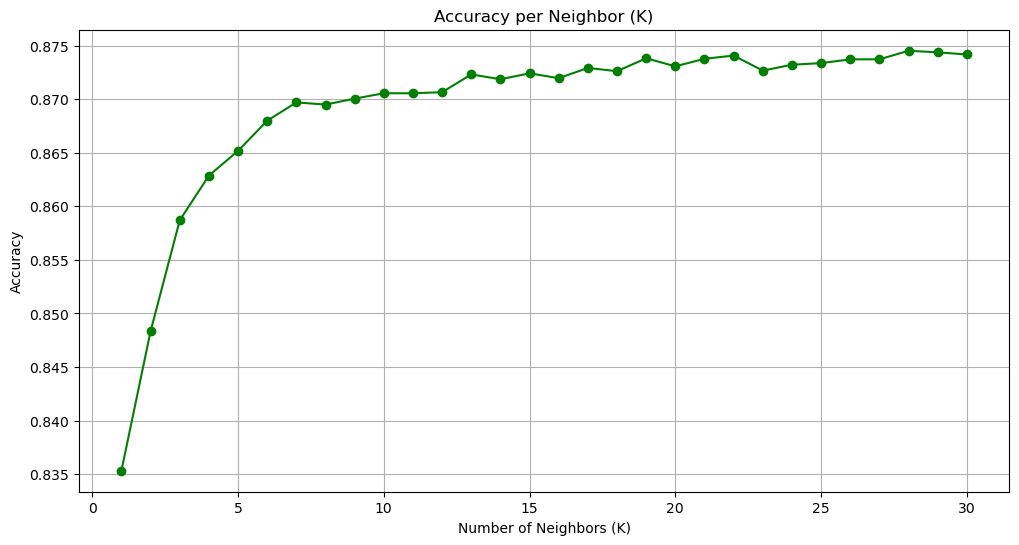

In [768]:
# Use grid search to search K in the range (1, 30) both inclusive...
parameter_grid = {'n_neighbors': range(1,31)}

# Create the machine learning model
knn_clf = KNeighborsClassifier()

# ...with 5-fold cross validation. The performance metric used for search is accuracy.
clf = GridSearchCV(knn_clf, parameter_grid, scoring = 'accuracy', cv = 5)
clf.fit(features, label)

# Create a variaable to store mean test scores for visualization
mean_scores1 = clf.cv_results_['mean_test_score']

# Visualise the performance change with respect to K using a line chart
plt.figure(figsize=(12, 6))
plt.plot(range(1,31), mean_scores1, marker='o', color='green')
plt.title('Accuracy per Neighbor (K)')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')

plt.grid(True)
plt.show()

The line chart shows the changes in accuracy as the number of neighbors increases. The accuracy gradually improved from neighbor 1 to 10, indicating that choosing more neighbors also increases the model's accuracy performance, and stabalized at neighbor 19. The chart does clearly not show the highest accuracy achieved among the neigbhors but this can be identified using clf.best_params_['neighbors'].

In [770]:
# Report the two performance metrics for the best case.

k = clf.best_params_['n_neighbors']
knn = KNeighborsClassifier(n_neighbors = k)
knn.fit(features, label)
y_pred = knn.predict(features)

# Accuracy and F1 Score of Best K
acc = accuracy_score(label, y_pred)
f1 = f1_score(label, y_pred)

print("Best K:", k)
print(f"Accuracy Score of Best K ({k}):", acc)
print(f"F1 Score of Best K ({k}):", f1)

Best K: 28
Accuracy Score of Best K (28): 0.8823618090452261
F1 Score of Best K (28): 0.7303927214096511


Results show that the best neighbor (best K) is 28 with an accuracy score of 88.24%, indicating the model's ability to correctly predict loan approval outcomes. An F1 score of 73.04% reflecting reasonable balance precision and recall, and capturing both approved and unapproved loans.

### Study how the distance metrics affect the model performance

In [773]:
# Build a KNN model with Euclidean as a metric
euc_knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
euc_knn.fit(features, label)

# Predict
y_pred = euc_knn.predict(features)

# Get Euclidean Accuracy and F1 Scores
euc_acc = accuracy_score(label, y_pred)
euc_f1 = f1_score(label, y_pred)

# Print results
print("Euclidean Metric")
print("Accuracy Score:", euc_acc)
print("F1 Score:",euc_f1)
print('------------------------------')

# Build a KNN model with L1 as a metric
l1_knn = KNeighborsClassifier(n_neighbors=k, metric='l1')
l1_knn.fit(features, label)

# Predict
y_pred = l1_knn.predict(features)

# Get L1 Accuracy and F1 Scores
l1_acc = accuracy_score(label, y_pred)
l1_f1 = f1_score(label, y_pred)

# Print results
print("L1 Metric")
print("Accuracy Score:", l1_acc)
print("F1 Score:", l1_f1)
print('------------------------------')

# Build a KNN model with Cosine as a metric
cos_knn = KNeighborsClassifier(n_neighbors=k, metric='cosine')
cos_knn.fit(features, label)

# Predict
y_pred = cos_knn.predict(features)

# Get Cosine Accuracy and F1 Scores
cos_acc = accuracy_score(label, y_pred)
cos_f1 = f1_score(label, y_pred)

# Print results
print("Cosine Metric")
print("Accuracy Score:", cos_acc)
print("F1 Score:", cos_f1)

Euclidean Metric
Accuracy Score: 0.8823618090452261
F1 Score: 0.7303927214096511
------------------------------
L1 Metric
Accuracy Score: 0.880854271356784
F1 Score: 0.7256739558023835
------------------------------
Cosine Metric
Accuracy Score: 0.871356783919598
F1 Score: 0.7087599544937428


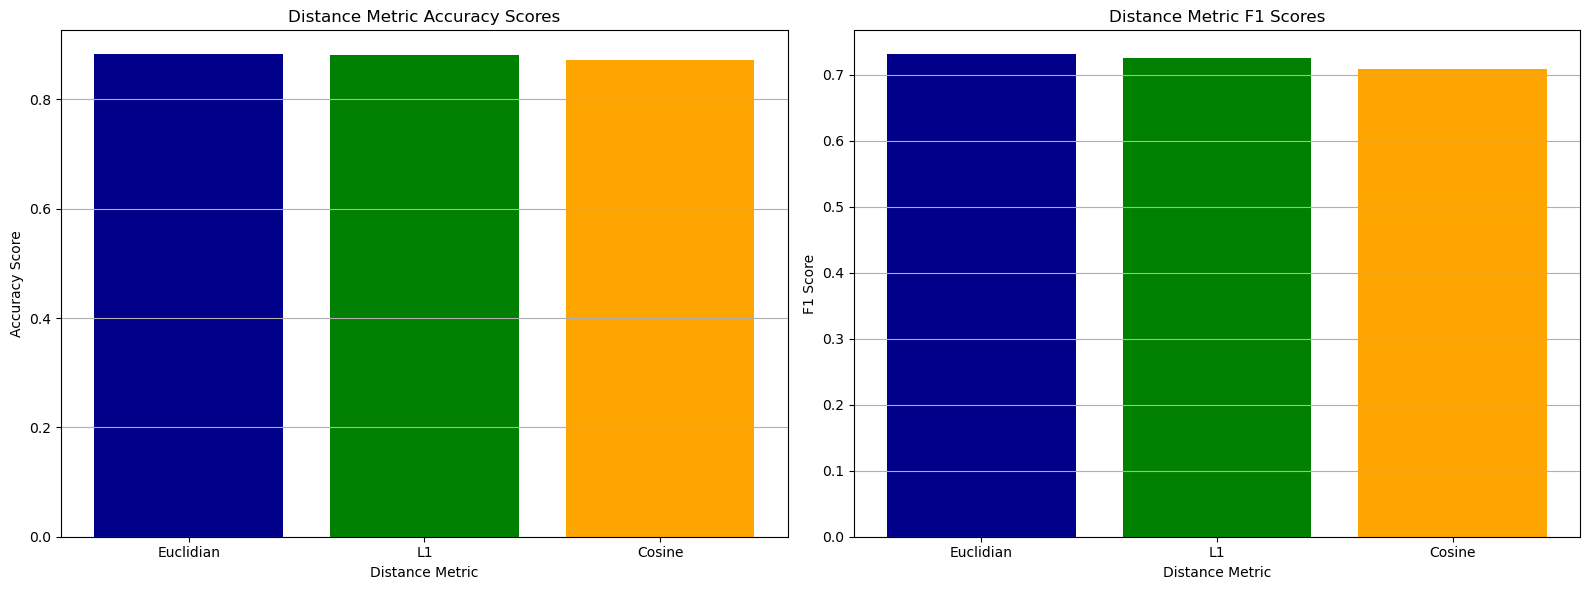

In [774]:
# Create new variables to store the distance metrics' performance scores for easier visualization
acc_scores = [euc_acc, l1_acc, cos_acc] # y label
f1_scores = [euc_f1, l1_f1, cos_f1] # y label
distance = ['Euclidian', 'L1', 'Cosine'] # x label

# Visualize
plt.figure(figsize = (16,6))

# Accuraccy Scores Bar Graph
plt.subplot(1,2,1)
plt.bar(distance, acc_scores, color = ['darkblue', 'green', 'orange'])
plt.title("Distance Metric Accuracy Scores")
plt.xlabel("Distance Metric")
plt.ylabel("Accuracy Score")
plt.grid(True, axis='y')

# F1 Scores Bar Graph
plt.subplot(1,2,2)
plt.bar(distance, f1_scores, color = ['darkblue', 'green', 'orange'])
plt.title("Distance Metric F1 Scores")
plt.xlabel("Distance Metric")
plt.ylabel("F1 Score")
plt.grid(True, axis='y')

plt.tight_layout()
plt.show()

**Euclidean**
* *Highest - Accuracy Score: 88.24%; F1 Score: 73.04%*
* Euclidean is the commonly used metric that measures the shortest path in a straight-line between two points.  

**L1**
* *Accuracy Score: 88.09%; F1 Score: 72.57%*
* L1 is measures the distance by only moving horizontally and vertically and calculates the absolute differences between points. This metric is advisable for data with numerous missing values and extreme values as it only measures the individual differences.  

**Cosine**
* *Lowest - Accuracy Score: 87.14%; F1 Score: 70.88%*
* Cosine is commonly used for text analysis and less advisable for numerical data.

Euclidean metric's accuracy and f1 scores performed the best among the three distance metrics as euclidean is best-suited for a clean numerical dataset. Although there's very little difference between Euclidean and L1 scores, L1 might be able to produce better results if the dataset had not been cleaned (removing null values, dropping rows and value imputation). Cosine had the worst performance compared to Euclidean and L1 since this metric is best-suited for text analysis. Despite this, cosine still scored a high accuracy and f1 score.